# MODULO6 -- TAE EN INTELIGENCIA ARTIFICIAL "IA"
# 🐲 🤖 👽 👏

 ## 🧑‍🏫 *Professor* 🧑‍🏫 : Dr Francisco Rodriguez

 ## 👨‍🎓 *Student*: 👨‍🎓 : Cesar Eduardo Inda Ceniceros

# TAE-IA · Module 6 · L04b — Automatic Masks: Semantic Segmentation for Inpainting

| | |
|---|---|
| **Module** | 6 — Practical AI Applications: Images and Audio |
| **Lesson** | L04b (companion to L04) |
| **Track** | A — Vision |
| **Estimated duration** | 45–60 minutes |
| **GPU required** | T4 (Colab) |
| **Prerequisites** | L01–L04 completed |

## Learning objectives
By the end of this notebook you will be able to:
- [ ] Generate a pixel-accurate mask automatically with a semantic segmentation model, instead of hand-coding rectangle coordinates
- [ ] Explain why segmentation masks still need dilation before inpainting
- [ ] Compare a hand-drawn rectangle mask against a segmentation-derived mask on the same source image and prompt
- [ ] Query a segmentation model for an arbitrary class and use it to drive inpainting

## Before you start
- L04 completed — this notebook assumes you already know why inpainting needs mask conditioning and why mask edges need feathering
- T4 GPU runtime selected (`Runtime > Change runtime type > T4 GPU`)

---

## Cell 0 — Setup (always run this first)

> Mounts Drive, checks GPU, fixes seed, and logs in to HuggingFace.

In [ ]:
# ================================================================
# TAE-IA M6 · Standard Setup -- DO NOT MODIFY THIS CELL
# ================================================================
import os, sys, random, shutil
import numpy as np

from google.colab import drive
drive.mount('/content/drive')

MODEL_CACHE = '/content/drive/MyDrive/TAE_IA_M6/models'
os.makedirs(MODEL_CACHE, exist_ok=True)
print(f'Model cache: {MODEL_CACHE}')

# Clear any cache left by earlier course versions.
for _leftover in ('hub', 'xet'):
    _p = os.path.join(MODEL_CACHE, _leftover)
    if os.path.exists(_p):
        shutil.rmtree(_p)

import torch
if not torch.cuda.is_available():
    print('\nNo GPU detected. Go to: Runtime > Change runtime type > T4 GPU')
    raise SystemExit('GPU required.')

gpu_name = torch.cuda.get_device_name(0)
vram_gb  = torch.cuda.get_device_properties(0).total_memory / 1e9
print(f'GPU: {gpu_name}  |  VRAM: {vram_gb:.1f} GB')

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
print(f'Fixed seed: {SEED}')
print(f'Python {sys.version.split()[0]}  |  PyTorch {torch.__version__}')

# HuggingFace login -- needed every new Colab session
import huggingface_hub

try:
    _token = huggingface_hub.get_token()
except Exception:
    _token = None

if _token:
    print(f"Already logged in to HuggingFace as: {huggingface_hub.whoami()['name']}")
else:
    try:
        from google.colab import userdata
        _hf_token = userdata.get('HF_TOKEN')
    except Exception:
        _hf_token = None

    if _hf_token:
        huggingface_hub.login(token=_hf_token, add_to_git_credential=False)
        print(f"Logged in to HuggingFace as: {huggingface_hub.whoami()['name']}")
    else:
        raise RuntimeError(
            'No HF_TOKEN found in Colab Secrets (key icon, left sidebar).\n'
            'Add a secret named HF_TOKEN with your HuggingFace read token, enable notebook access, '
            'then re-run this cell.\n'
            'See L00 Cell 4 if you need to generate a token or accept the SD 1.5 license.'
        )

In [ ]:
# ================================================================
# Install dependencies for L04b
# ================================================================
!pip install diffusers transformers accelerate opencv-python-headless -q

import diffusers, cv2, transformers
print(f'diffusers {diffusers.__version__}  |  OpenCV {cv2.__version__}  |  transformers {transformers.__version__}')

diffusers 0.39.0  |  OpenCV 4.14.0  |  transformers 5.15.0


---
## Part 1 — Context and Key Concepts

> Read this before running any code.

### From coordinates to queries

Every mask in L04 was **hand-drawn**: a rectangle, an ellipse, a polygon — all defined by pixel coordinates you picked by eye. That does not scale. You cannot hardcode `(140, 200), (380, 390)` for a thousand product photos, and a mask that hugs a real object's silhouette (not a rectangle) is hard to draw by hand at all.

A **semantic segmentation model** turns mask creation into a query: instead of *"here are the coordinates,"* you ask *"give me the sky"* or *"give me the person,"* and the model returns a pixel-accurate mask for that class.

### The model: SegFormer on ADE20K

`nvidia/segformer-b0-finetuned-ade-512-512` is a semantic segmentation model trained on **ADE20K**, a scene-segmentation dataset with about 150 categories (sky, building, tree, person, road, mountain, water, …). It is small (the `-b0` variant) and fast enough to run comfortably on a T4 **alongside** the inpainting checkpoint — no need to free VRAM between them.

The `transformers` `image-segmentation` pipeline returns one dictionary per detected class, each with a `label` and a `mask` (a PIL image, white = that class, same size as the input). It also has a `score` key, but for a *semantic* model like this one it is always `None` — every pixel gets assigned exactly one class, so there is no per-region confidence to report. `score` only carries a real number for instance/panoptic segmentation models, where the pipeline is picking out separate object instances.

### Segmentation masks still need dilation

This is the detail that catches people off guard: a segmentation mask follows the object's silhouette **exactly**, pixel for pixel. That is precisely the *"mask hugs the object exactly"* failure mode from L04's mask-design discussion — the boundary latent block is only partially masked, so a sliver of the old content survives and the model dutifully blends toward it, leaving a ghost outline.

The fix is the same one L04 taught for hand-drawn masks: **dilate before you inpaint.**

```python
seg_mask_dilated = cv2.dilate(seg_mask_raw, np.ones((15, 15), np.uint8))
```

A pixel-perfect mask is not automatically a *good* mask — it needs the same 10–20px of breathing room as a rectangle you drew by hand.

### Where this is going

Segmentation feeding inpainting is a **two-model vision pipeline** — exactly the pattern L11 builds several of (e.g. automatic background replacement, real-estate sky replacement, privacy tools that blur faces at scale). SAM (Segment Anything, Meta) is the other option worth knowing about: instead of a fixed label set, you prompt it with a point or a box and it returns a mask for whatever object is there — more flexible, larger, and slower. Use SegFormer for known categories, SAM for arbitrary objects.

---

## Part 2 — Lab

### Section 2.1 — Source image and inpainting pipeline

Same source and same inpainting checkpoint as L04. If you already ran L04 in this Drive, the snapshots are cached and this cell will be fast.

Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

txt2img loaded.


  0%|          | 0/25 [00:00<?, ?it/s]

Source saved: (512, 512)
VRAM freed. Available: 15.6 GB


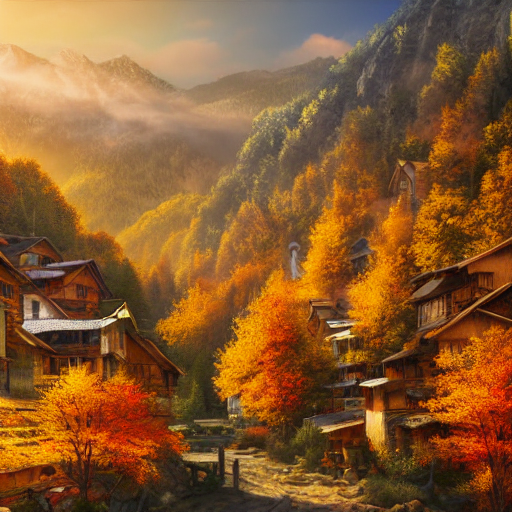

In [ ]:
# Section 2.1a -- Generate source image with txt2img (same prompt/seed as L04)
from diffusers import StableDiffusionPipeline
from huggingface_hub import snapshot_download
import torch, gc, os
import matplotlib.pyplot as plt

OUTPUT_DIR = '/content/drive/MyDrive/TAE_IA_M6/L04b_output'
os.makedirs(OUTPUT_DIR, exist_ok=True)

def gen(seed=SEED):
    return torch.Generator("cuda").manual_seed(seed)

SD15_DIR = os.path.join(MODEL_CACHE, 'sd15-local')
snapshot_download(
    "runwayml/stable-diffusion-v1-5",
    local_dir=SD15_DIR,
    allow_patterns=["*.json", "*.txt", "*.fp16.safetensors"],
)

pipe_txt = StableDiffusionPipeline.from_pretrained(
    SD15_DIR,
    torch_dtype=torch.float16,
    variant="fp16",
).to("cuda")
print("txt2img loaded.")

SOURCE_PROMPT = "a mountain village in autumn, warm golden light, photorealistic, high detail"

source = pipe_txt(
    SOURCE_PROMPT,
    num_inference_steps=25,
    guidance_scale=7.5,
    generator=gen()
).images[0]
source_512 = source.resize((512, 512))
source_512.save(os.path.join(OUTPUT_DIR, "l04b_source.png"))
print(f"Source saved: {source_512.size}")

del pipe_txt; gc.collect(); torch.cuda.empty_cache()
print(f"VRAM freed. Available: {(torch.cuda.get_device_properties(0).total_memory - torch.cuda.memory_allocated(0))/1e9:.1f} GB")

source_512

In [ ]:
# Section 2.1b -- Load inpainting pipeline
from diffusers import StableDiffusionInpaintPipeline

INPAINT_DIR = os.path.join(MODEL_CACHE, 'sd15-inpainting-local')
snapshot_download(
    "runwayml/stable-diffusion-inpainting",
    local_dir=INPAINT_DIR,
    allow_patterns=["*.json", "*.txt", "*.fp16.safetensors"],
)

pipe_inp = StableDiffusionInpaintPipeline.from_pretrained(
    INPAINT_DIR,
    torch_dtype=torch.float16,
    variant="fp16",
).to("cuda")
print("Inpainting pipeline loaded.")

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 16 files:   0%|          | 0/16 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

Inpainting pipeline loaded.


### Section 2.2 — Baseline: hand-drawn rectangle mask

Same as L04 Section 2.2 — the top 35% of the frame, hardcoded. This is the mask we will compare the automatic one against.

  0%|          | 0/25 [00:00<?, ?it/s]

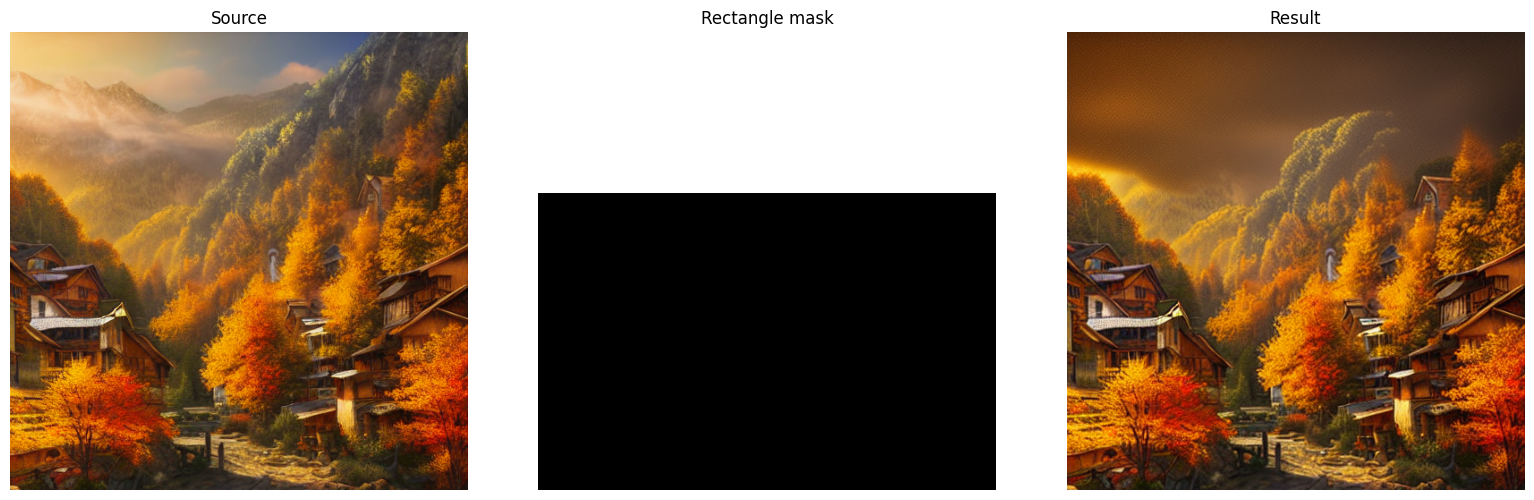

In [ ]:
# Section 2.2 -- Hand-drawn rectangle sky mask (baseline, same as L04)
import cv2
import numpy as np
from PIL import Image

rect_hard = np.zeros((512, 512), dtype=np.uint8)
rect_hard[:180, :] = 255
rect_soft = cv2.GaussianBlur(rect_hard, (31, 31), 0)

SKY_PROMPT = "dramatic stormy sky, dark storm clouds, volumetric lighting, cinematic"

rect_result = pipe_inp(
    prompt              = SKY_PROMPT,
    image               = source_512,
    mask_image          = Image.fromarray(rect_soft),
    num_inference_steps = 25,
    guidance_scale      = 7.5,
    generator           = gen()
).images[0]
rect_result.save(os.path.join(OUTPUT_DIR, "rect_mask_result.png"))

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
axes[0].imshow(source_512); axes[0].set_title("Source"); axes[0].axis('off')
axes[1].imshow(rect_hard, cmap='gray'); axes[1].set_title("Rectangle mask"); axes[1].axis('off')
axes[2].imshow(rect_result); axes[2].set_title("Result"); axes[2].axis('off')
plt.tight_layout(); plt.savefig(os.path.join(OUTPUT_DIR, "rect_mask_comparison.png"), dpi=100); plt.show()

### Section 2.3 — Automatic mask via semantic segmentation

Query the segmentation model for the `"sky"` class instead of hand-coding coordinates.

config.json:   0%|          | 0.00/6.88k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 15.0MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/208 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/271 [00:00<?, ?B/s]

Detected labels, largest region first:
  tree           93375 px
  mountain       81273 px
  house          46300 px
  sky            23967 px
  earth          12839 px
  plant           2203 px
  car             1840 px
  building         257 px
  wall              51 px
  fence             39 px
Sky region area: 23967 px  |  score: None


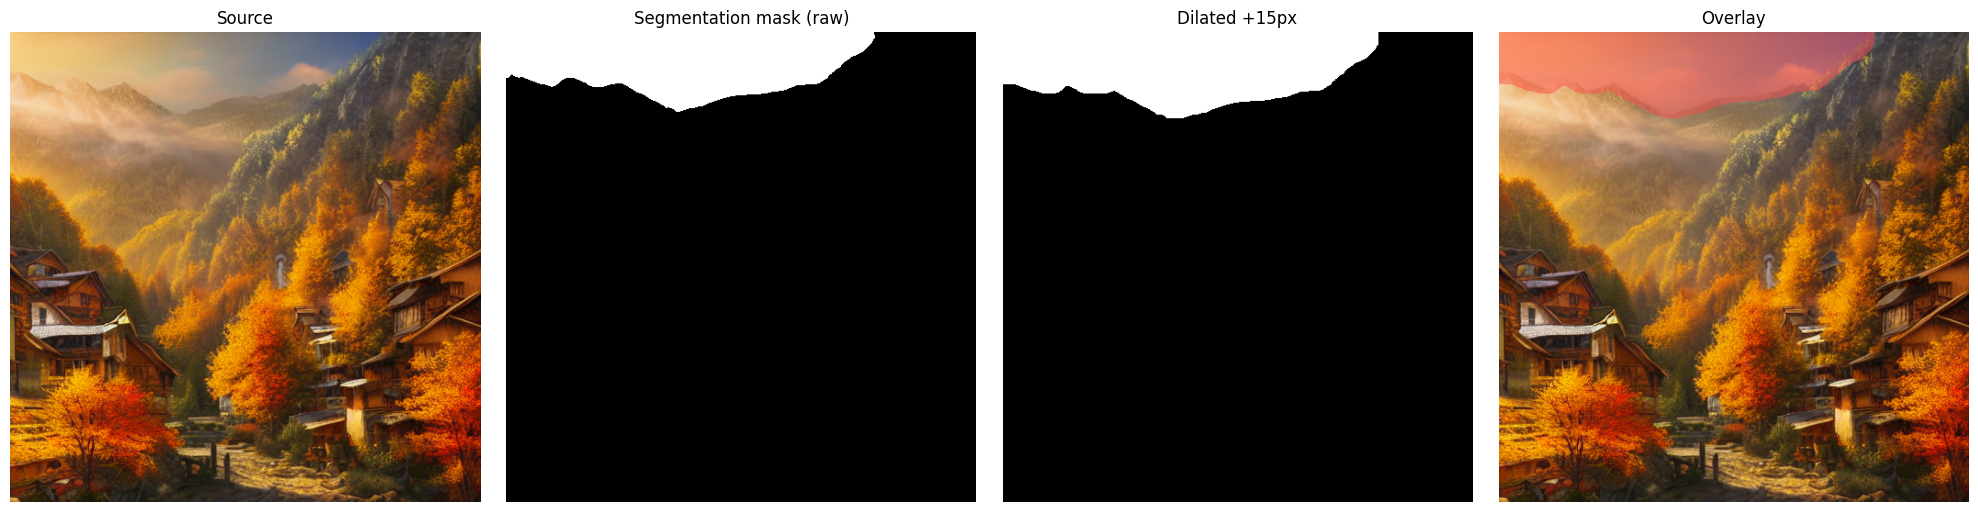

In [ ]:
# Section 2.3a -- Generate the sky mask automatically
from transformers import pipeline as hf_pipeline

segmenter = hf_pipeline(
    "image-segmentation",
    model="nvidia/segformer-b0-finetuned-ade-512-512",
    device=0,
)

segments = segmenter(source_512)

def area_of(seg):
    return int((np.array(seg["mask"]) == 255).sum())

print("Detected labels, largest region first:")
for s in sorted(segments, key=area_of, reverse=True):
    print(f"  {s['label']:<12} {area_of(s):>7} px")

sky_segment = next((s for s in segments if s["label"].lower() == "sky"), None)
if sky_segment is None:
    raise RuntimeError(
        "No 'sky' region detected in this source image. "
        "Inspect the labels printed above and adapt the filter to a class that IS present "
        "(e.g. 'building', 'tree', 'mountain')."
    )

seg_mask_raw = np.array(sky_segment["mask"])   # 0/255, pixel-accurate to the sky silhouette
# `score` is only populated for instance/panoptic segmentation -- semantic models like
# SegFormer assign every pixel a class with no per-region confidence, so it comes back None.
print(f"Sky region area: {area_of(sky_segment)} px  |  score: {sky_segment['score']}")

# Segmentation masks hug the silhouette exactly -- same tight-mask problem as a hand-drawn
# mask that traces an object outline. Dilate before using it for inpainting.
seg_mask_dilated = cv2.dilate(seg_mask_raw, np.ones((15, 15), np.uint8))
seg_mask_soft = cv2.GaussianBlur(seg_mask_dilated, (31, 31), 0)

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
axes[0].imshow(source_512); axes[0].set_title("Source"); axes[0].axis('off')
axes[1].imshow(seg_mask_raw, cmap='gray'); axes[1].set_title("Segmentation mask (raw)"); axes[1].axis('off')
axes[2].imshow(seg_mask_dilated, cmap='gray'); axes[2].set_title("Dilated +15px"); axes[2].axis('off')
overlay_seg = np.array(source_512.convert("RGB")).copy()
overlay_seg[seg_mask_dilated == 255] = (
    overlay_seg[seg_mask_dilated == 255] * 0.5 + np.array([255, 80, 80]) * 0.5
).astype(np.uint8)
axes[3].imshow(overlay_seg); axes[3].set_title("Overlay"); axes[3].axis('off')
plt.tight_layout(); plt.savefig(os.path.join(OUTPUT_DIR, "auto_mask_preview.png"), dpi=100); plt.show()

  0%|          | 0/25 [00:00<?, ?it/s]

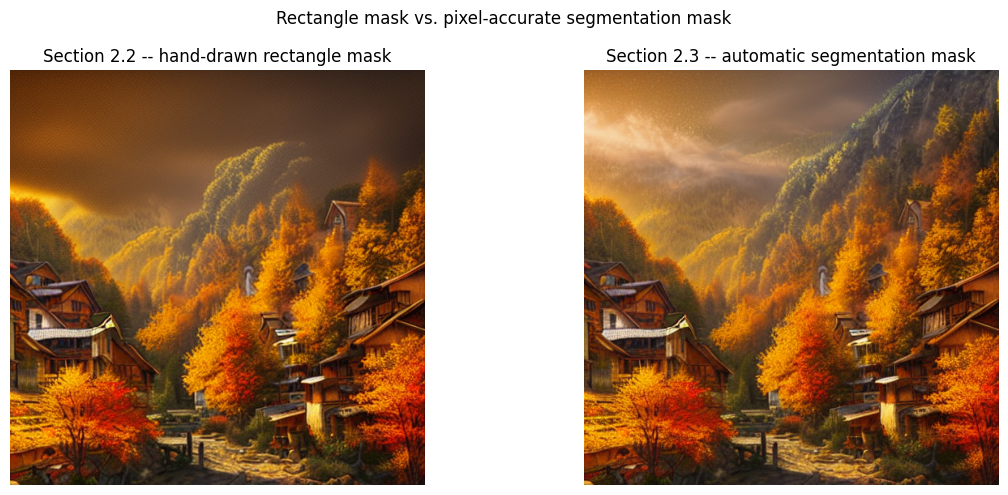

In [ ]:
# Section 2.3b -- Inpaint with the automatic mask, same prompt/seed as the rectangle baseline
auto_result = pipe_inp(
    prompt              = SKY_PROMPT,
    image               = source_512,
    mask_image          = Image.fromarray(seg_mask_soft),
    num_inference_steps = 25,
    guidance_scale      = 7.5,
    generator           = gen()
).images[0]
auto_result.save(os.path.join(OUTPUT_DIR, "auto_mask_result.png"))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(rect_result); axes[0].set_title("Section 2.2 -- hand-drawn rectangle mask"); axes[0].axis('off')
axes[1].imshow(auto_result); axes[1].set_title("Section 2.3 -- automatic segmentation mask"); axes[1].axis('off')
plt.suptitle("Rectangle mask vs. pixel-accurate segmentation mask", fontsize=12)
plt.tight_layout(); plt.savefig(os.path.join(OUTPUT_DIR, "auto_mask_comparison.png"), dpi=100); plt.show()

**What do you observe?**
- Does the segmentation mask follow the real sky/roofline boundary more precisely than the rectangle from Section 2.2?
- Compare `auto_mask_comparison.png` to `rect_mask_comparison.png` — where does the automatic mask produce a cleaner seam, and where (if anywhere) does it produce a worse one?
- The rectangle cut straight across the roofline in L04. Did the segmentation mask avoid that problem?

*Write your observation here:*

### Section 2.3 — Observation

The automatic segmentation mask follows the real sky and roofline more precisely than the rectangular mask. The rectangle covers the complete top part of the image and cuts across some roofs, trees, and mountains.

The automatic mask produces a cleaner seam around the roofs and mountains because it selects pixels classified as sky. It avoids changing most of the buildings. However, some small areas around tree branches can look less clean because their shapes are thin and complex.

Overall, the segmentation mask avoids the straight horizontal cut created by the rectangle.

### Section 2.4 — Querying an arbitrary class

The point of segmentation-driven masking is that it generalizes: swap the label string and you mask something else entirely, with no new coordinates to figure out.

**Three catches:**
1. A class name matching something in the scene doesn't guarantee a *usable* mask. ADE20K sometimes splits one visual structure across two labels (e.g. the village's cottages here are `"house"`, not `"building"`) — picking the wrong one of the two gives you a near-empty mask that inpainting can barely touch. Check the region sizes printed in Section 2.3a before picking a target; this is the same "mask far too small" failure from L04, just arrived at through a class name instead of a hand-drawn rectangle.
2. A **semantic** mask is the union of *every* instance of that class in the frame. If there are five houses scattered across the image, `"house"` gives you five disconnected blobs in one mask, not one house's silhouette. Asking the model to paint "a stone watchtower" across five scattered islands doesn't describe one coherent object, so it tends to just blend each island into its local surroundings instead — you get houses quietly erased, not a watchtower. The fix: isolate the single largest **connected component** within the class mask before inpainting. (This is exactly the gap a point-prompted model like SAM closes — it returns one instance directly, with no connected-component step needed.)
3. Even with one clean instance masked, a distinctive prompt can still lose to strong surrounding context. This scene is a dense autumn forest — the UNet sees a lot of "trees, warm colors" in the unmasked context, and at a moderate `guidance_scale` the path of least resistance is to just continue that context rather than commit to something as different as a stone tower. Two levers fix this: push `guidance_scale` noticeably higher (double digits, not 7–8), and add a `negative_prompt` that explicitly excludes the surrounding content you don't want bleeding in.

Using 'house': 46300 px across the whole class, 22793 px in the single largest instance we'll inpaint.


  0%|          | 0/35 [00:00<?, ?it/s]

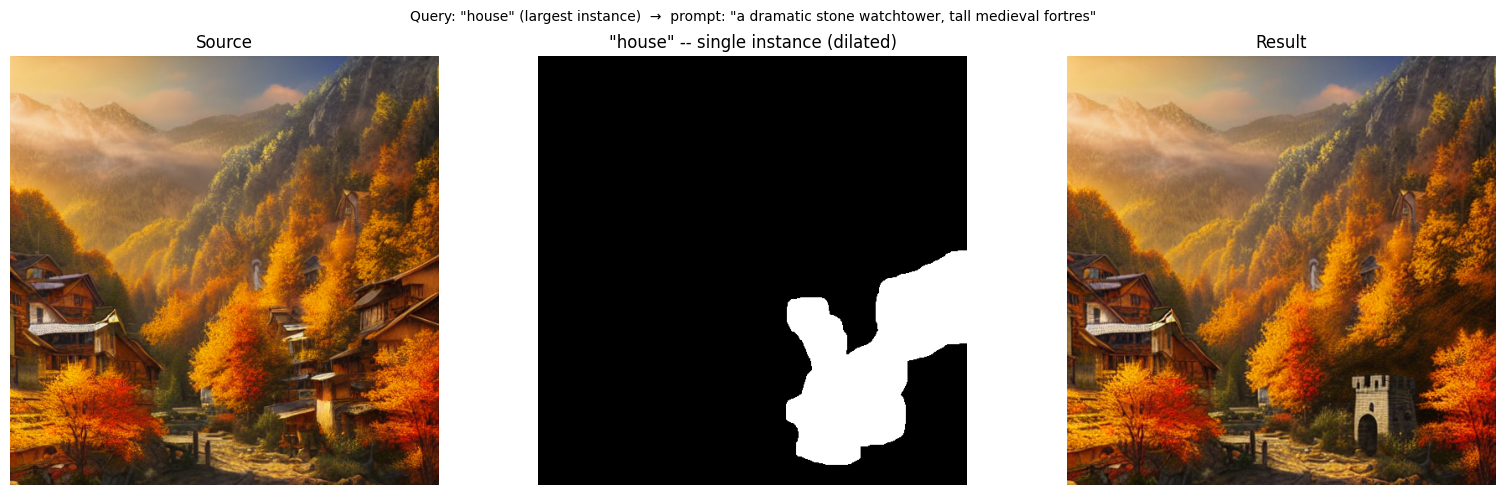

In [ ]:
# Section 2.4 -- Pick a class other than "sky" to drive a different edit.
# "house" and "building" both denote village structures in ADE20K, but in a given image
# one of them may match only a tiny, unrelated patch -- so we take the LARGER of the two
# rather than hardcoding a single name, and guard against a mask that's too small to matter.
CANDIDATE_LABELS = ["house", "building"]
MIN_MASK_AREA = 800   # px -- below this, inpainting has too little room to change anything visible

target_segment = max(
    (s for s in segments if s["label"].lower() in CANDIDATE_LABELS),
    key=area_of,
    default=None,
)

def largest_connected_component(mask_uint8):
    # The class mask is the union of EVERY house in the frame -- several disconnected blobs,
    # not one house's silhouette. Asking for "a watchtower" across scattered islands doesn't
    # describe one object, so isolate the single largest connected blob and inpaint just that.
    num_labels, labels_im, stats, _ = cv2.connectedComponentsWithStats(mask_uint8, connectivity=8)
    if num_labels <= 1:            # no foreground pixels at all
        return mask_uint8
    largest_label = 1 + int(np.argmax(stats[1:, cv2.CC_STAT_AREA]))   # skip label 0 = background
    return np.where(labels_im == largest_label, 255, 0).astype(np.uint8)

if target_segment is None:
    print(f"None of {CANDIDATE_LABELS} found. Available labels: {[s['label'] for s in segments]}")
else:
    TARGET_LABEL = target_segment["label"]
    full_class_mask = np.array(target_segment["mask"])
    target_mask_raw = largest_connected_component(full_class_mask)
    instance_area = int((target_mask_raw == 255).sum())

    if instance_area < MIN_MASK_AREA:
        print(f"Largest '{TARGET_LABEL}' instance is only {instance_area} px -- too small to "
              f"produce a visible change. Pick a larger label from the sizes printed in Section 2.3a.")
    else:
        print(f"Using '{TARGET_LABEL}': {area_of(target_segment)} px across the whole class, "
              f"{instance_area} px in the single largest instance we'll inpaint.")

        target_mask_dilated = cv2.dilate(target_mask_raw, np.ones((15, 15), np.uint8))
        target_mask_soft = cv2.GaussianBlur(target_mask_dilated, (31, 31), 0)

        TARGET_PROMPT = ("a dramatic stone watchtower, tall medieval fortress tower, dark grey stone "
                          "blocks, narrow arrow-slit windows, weathered, sharp architectural edges, "
                          "photorealistic, isolated distinct structure")
        # Even a good prompt loses a tug-of-war against strong surrounding context (autumn forest,
        # warm colors) at a moderate guidance_scale -- the model has a real incentive to just
        # continue what's around the mask. Push guidance higher and explicitly exclude the
        # surrounding content so the prompt wins that tug-of-war instead of "blending away."
        NEGATIVE_PROMPT = "trees, forest, foliage, leaves, greenery, blurry, blending into background"

        target_result = pipe_inp(
            prompt              = TARGET_PROMPT,
            negative_prompt     = NEGATIVE_PROMPT,
            image               = source_512,
            mask_image          = Image.fromarray(target_mask_soft),
            num_inference_steps = 35,
            guidance_scale      = 13.0,
            generator           = gen()
        ).images[0]
        target_result.save(os.path.join(OUTPUT_DIR, "other_class_result.png"))

        fig, axes = plt.subplots(1, 3, figsize=(16, 5))
        axes[0].imshow(source_512); axes[0].set_title("Source"); axes[0].axis('off')
        axes[1].imshow(target_mask_dilated, cmap='gray'); axes[1].set_title(f'"{TARGET_LABEL}" -- single instance (dilated)'); axes[1].axis('off')
        axes[2].imshow(target_result); axes[2].set_title("Result"); axes[2].axis('off')
        plt.suptitle(f'Query: "{TARGET_LABEL}" (largest instance)  →  prompt: "{TARGET_PROMPT[:50]}"', fontsize=10)
        plt.tight_layout(); plt.savefig(os.path.join(OUTPUT_DIR, "other_class_comparison.png"), dpi=100); plt.show()

**What do you observe?**
- Compare the printed "whole class" area to the "single largest instance" area — how much of the `"house"` mask got discarded by the connected-component step, and does that match what you'd expect from counting houses in the source image?
- Does the result actually read as a watchtower now, with `guidance_scale=13` and a `negative_prompt`? If you drop back to `guidance_scale=7.5` with no negative prompt on the same mask, what changes?
- Is the dilated single-instance mask still tight enough to preserve the rest of the scene, or did it eat into neighboring regions?

*Write your observation here:*

### Section 2.4 — Observation

The complete `house` class contained 46,300 pixels. After selecting the largest connected component, 22,793 pixels remained. Therefore, 23,507 pixels, or about 50.8% of the original mask, were discarded. This is reasonable because the source image contains several separate houses.

With `guidance_scale=13` and the negative prompt, the generated structure looks more like a stone watchtower. The stronger guidance helps the model follow the text instead of continuing the trees and autumn colors.

With `guidance_scale=7.5` and no negative prompt, the model would probably follow the surrounding forest more strongly. The result could look more like a house, trees, or a blended part of the landscape instead of a clear watchtower.

The dilated single-instance mask remains focused on the largest house. It preserves most of the scene, but it may change a small area around the house because dilation expands the mask beyond its original boundary.

---
## Part 3 — Exercises

### Exercise 1 — Segment and inpaint a class of your choice

**Task:** From the labels printed in Section 2.3a, pick a class that was **not** used above (not `sky`, not the Section 2.4 target). Extract its mask, dilate it, and run inpainting with a prompt of your choice.

**Expected output:** source + raw segmentation mask + dilated mask + result. In a markdown cell: was the raw (non-dilated) mask usable on its own, or did it need the same 10–20px correction as every mask in L04?

Selected class: tree
Raw mask area: 93375 pixels
Dilated mask area: 122466 pixels


  0%|          | 0/35 [00:00<?, ?it/s]

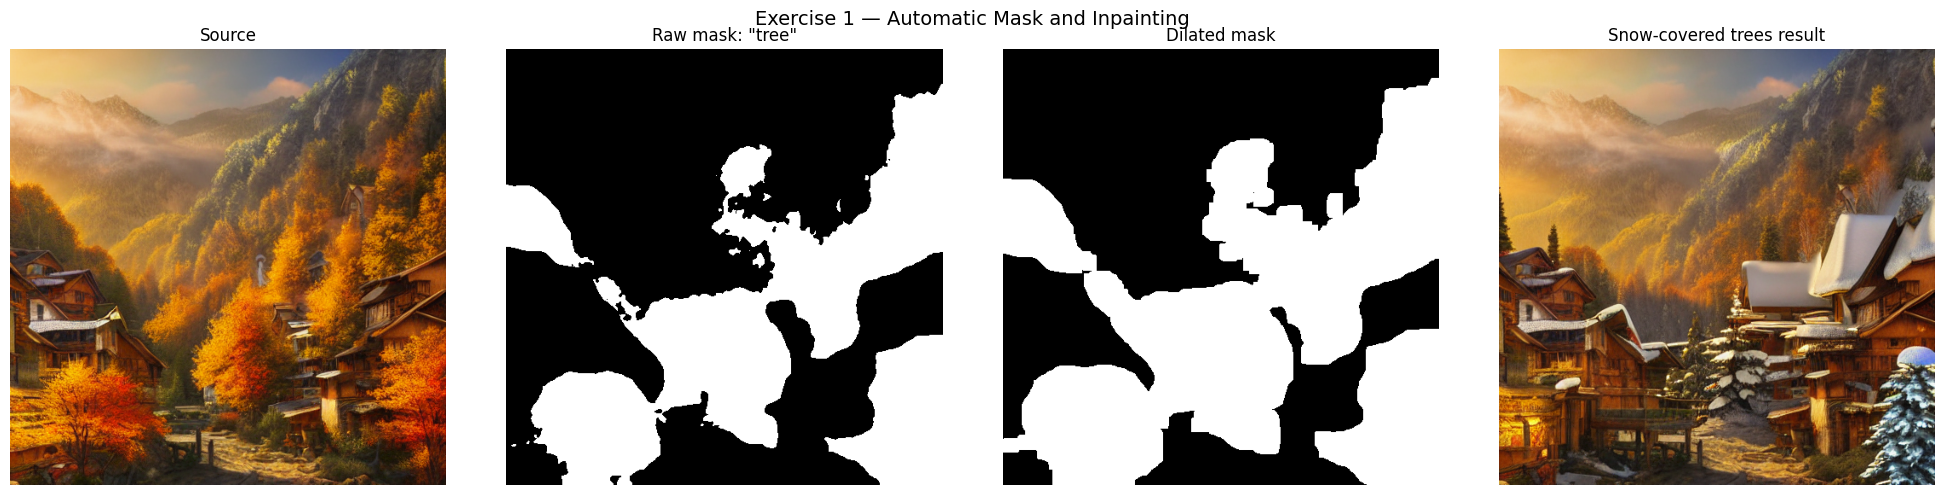

Exercise 1 completed.
Comparison saved as exercise1.png


In [ ]:
# Exercise 1 -- segment + inpaint a class of your choice
# Remember: save any images to OUTPUT_DIR, e.g. img.save(os.path.join(OUTPUT_DIR, "exercise1.png"))
# Pick a label from the list printed in Section 2.3a and repeat the mask -> dilate -> inpaint flow
# ...
# Exercise 1 -- Segment and inpaint a class of your choice
# Selected class: "car"
# The car will be replaced with a golden eagle.

EXERCISE1_LABEL = "tree"

exercise1_segment = next(
    (
        s for s in segments
        if s["label"].lower() == EXERCISE1_LABEL
    ),
    None
)

if exercise1_segment is None:
    raise RuntimeError(
        f"The class '{EXERCISE1_LABEL}' was not detected. "
        "Select another class from the printed label list."
    )

# ---------------------------------------------------------
# 1. Extract the raw segmentation mask
# ---------------------------------------------------------

exercise1_mask_raw = np.array(
    exercise1_segment["mask"]
).astype(np.uint8)

raw_area = int(
    (exercise1_mask_raw == 255).sum()
)

print(
    f"Selected class: {EXERCISE1_LABEL}"
)

print(
    f"Raw mask area: {raw_area} pixels"
)

# ---------------------------------------------------------
# 2. Dilate and soften the mask
# ---------------------------------------------------------

exercise1_mask_dilated = cv2.dilate(
    exercise1_mask_raw,
    np.ones((15, 15), dtype=np.uint8),
    iterations=1
)

exercise1_mask_soft = cv2.GaussianBlur(
    exercise1_mask_dilated,
    (31, 31),
    0
)

dilated_area = int(
    (exercise1_mask_dilated == 255).sum()
)

print(
    f"Dilated mask area: {dilated_area} pixels"
)

# Save the masks
Image.fromarray(exercise1_mask_raw).save(
    os.path.join(
        OUTPUT_DIR,
        "exercise1_raw_mask.png"
    )
)

Image.fromarray(exercise1_mask_dilated).save(
    os.path.join(
        OUTPUT_DIR,
        "exercise1_dilated_mask.png"
    )
)

# ---------------------------------------------------------
# 3. Run inpainting
# ---------------------------------------------------------

EXERCISE1_PROMPT = (
    "snow-covered pine trees, winter forest, white snow on branches, "
    "cold natural light, photorealistic, high detail"
)

EXERCISE1_NEGATIVE_PROMPT = (
    "autumn trees, orange leaves, golden leaves, blurry, "
    "cartoon, painting, text, watermark"
)

exercise1_result = pipe_inp(
    prompt=EXERCISE1_PROMPT,
    negative_prompt=EXERCISE1_NEGATIVE_PROMPT,
    image=source_512,
    mask_image=Image.fromarray(exercise1_mask_soft),
    num_inference_steps=35,
    guidance_scale=11.0,
    generator=gen(SEED + 10)
).images[0]

exercise1_result.save(
    os.path.join(
        OUTPUT_DIR,
        "exercise1_eagle_result.png"
    )
)

# ---------------------------------------------------------
# 4. Show source, raw mask, dilated mask, and result
# ---------------------------------------------------------

fig, axes = plt.subplots(
    1,
    4,
    figsize=(20, 5)
)

axes[0].imshow(source_512)
axes[0].set_title("Source")
axes[0].axis("off")

axes[1].imshow(
    exercise1_mask_raw,
    cmap="gray"
)
axes[1].set_title(
    f'Raw mask: "{EXERCISE1_LABEL}"'
)
axes[1].axis("off")

axes[2].imshow(
    exercise1_mask_dilated,
    cmap="gray"
)
axes[2].set_title("Dilated mask")
axes[2].axis("off")

axes[3].imshow(exercise1_result)
axes[3].set_title("Snow-covered trees result")
axes[3].axis("off")

plt.suptitle(
    "Exercise 1 — Automatic Mask and Inpainting",
    fontsize=14
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "exercise1.png"
    ),
    dpi=120,
    bbox_inches="tight"
)

plt.show()

print("Exercise 1 completed.")
print("Comparison saved as exercise1.png")

*Was the raw segmentation mask usable without dilation? What changed once you dilated it?*

### Exercise 1 — Observation

I selected the `tree` class. The raw mask detected several tree regions across the image, not only one tree. It also contained complex and disconnected shapes because the trees overlap with houses, mountains, and other vegetation.

The raw mask was too close to some branches and leaves. After dilation, small gaps were closed and the model had more space to replace the autumn vegetation. The result shows snow-covered trees, especially near the houses and in the lower-right area.

The dilation improved the completeness of the edit. However, it also expanded into some nearby buildings. This created white areas on a few roofs and structures. Therefore, the raw mask needed correction, but excessive expansion can also modify neighboring regions.

### Exercise 2 — Skip the dilation, on purpose

**Task:** Re-run the sky replacement from Section 2.3b using `seg_mask_raw` directly (no dilation, no blur — just `Image.fromarray(seg_mask_raw)`), same prompt and seed. Compare it to the dilated result.

**Expected output:** side-by-side of the dilated result (Section 2.3b) vs. the raw-mask result. In a markdown cell: describe the specific artifact at the roofline, in image terms — not just "it looks worse.

  0%|          | 0/25 [00:00<?, ?it/s]

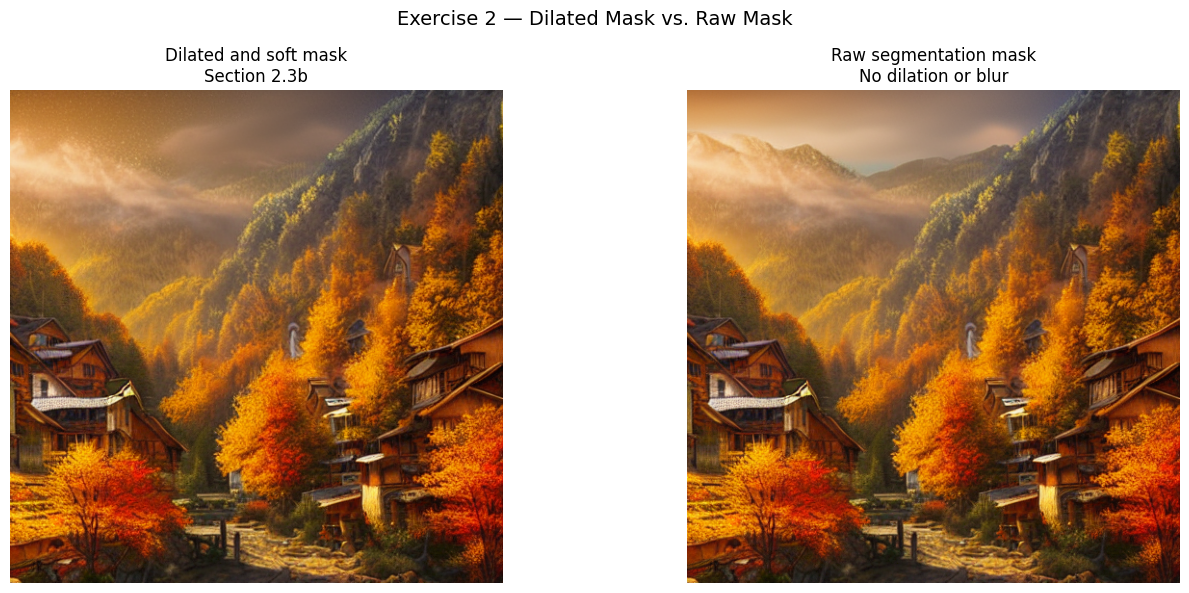

Exercise 2 completed.
Comparison saved as exercise2.png


In [ ]:
# Exercise 2 -- inpaint with the RAW (non-dilated) segmentation mask, same prompt/seed
# Remember: save any images to OUTPUT_DIR, e.g. img.save(os.path.join(OUTPUT_DIR, "exercise2.png"))
# ...

# Exercise 2 -- Use the raw segmentation mask on purpose
# No dilation and no Gaussian blur.

raw_sky_result = pipe_inp(
    prompt=SKY_PROMPT,
    image=source_512,

    # Use the raw mask directly, as requested
    mask_image=Image.fromarray(seg_mask_raw),

    num_inference_steps=25,
    guidance_scale=7.5,

    # Same seed as Section 2.3b
    generator=gen()
).images[0]

raw_sky_result.save(
    os.path.join(
        OUTPUT_DIR,
        "exercise2_raw_mask_result.png"
    )
)

# ---------------------------------------------------------
# Compare the dilated result with the raw-mask result
# ---------------------------------------------------------

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 6)
)

axes[0].imshow(auto_result)
axes[0].set_title(
    "Dilated and soft mask\nSection 2.3b"
)
axes[0].axis("off")

axes[1].imshow(raw_sky_result)
axes[1].set_title(
    "Raw segmentation mask\nNo dilation or blur"
)
axes[1].axis("off")

plt.suptitle(
    "Exercise 2 — Dilated Mask vs. Raw Mask",
    fontsize=14
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "exercise2.png"
    ),
    dpi=120,
    bbox_inches="tight"
)

plt.show()

print("Exercise 2 completed.")
print("Comparison saved as exercise2.png")

*Describe the artifact at the boundary when the mask isn't dilated:*

### Exercise 2 — Observation

The difference between the two results is subtle. The raw segmentation mask produces a sharper boundary between the sky and the mountain. However, a thin trace of the original sky remains near parts of the mountain edge and around small tree details.

The dilated and soft mask covers a slightly larger area. It creates a smoother transition between the generated sky and the mountain. It also reduces the risk of leaving an outline from the original sky.

The raw mask follows the detected boundary accurately, but it does not give the inpainting model enough extra space to replace all boundary pixels.

---
## Part 4 — Critical Analysis

> Required. Answer with real outputs from today's session.

**4.1 — Seam comparison: comparing `rect_mask_comparison.png` (Section 2.2) and `auto_mask_comparison.png` (Section 2.3) at the roofline — which mask produced the cleaner seam, and why, given what you know about where each mask boundary falls relative to the actual sky/roof edge?**

The automatic segmentation mask produced a cleaner seam than the rectangular mask. The rectangle used a straight horizontal boundary, so it also covered parts of the mountains, trees, and buildings.

The automatic mask followed the real boundary between the sky and the mountain more closely. It preserved more of the original landscape and avoided cutting directly across the roofs. However, some small artifacts remained near thin branches and complex mountain edges.

---

**4.2 — Dilation necessity: segmentation masks are pixel-accurate to the object silhouette, yet Section 2.3a dilated the mask by 15px anyway before inpainting. Why does a pixel-accurate mask still need this correction? Connect your answer to the 64×64 latent downsampling from L04.**

A pixel-accurate segmentation mask is still too close to the exact object boundary. Stable Diffusion processes the 512 × 512 image in a 64 × 64 latent space. Therefore, one latent pixel represents approximately an 8 × 8 block of image pixels.

At the boundary, one latent block can contain both masked and unmasked pixels. Part of the original content can remain and create a thin outline or ghost edge. Dilation adds extra pixels around the region, so the complete boundary is included in the inpainting area. The soft mask also creates a smoother transition.

---

**4.3 — Generalization: Section 2.4 swapped one string (`TARGET_LABEL`) to mask a completely different region. What would it take to do the equivalent with the hand-drawn rectangle approach from L04, for the same target class across many different source images?**

With semantic segmentation, changing the target can be as simple as changing a class label, for example from `sky` to `tree`. The model finds the position and shape of that class automatically.

With hand-drawn rectangles, we would need to inspect every source image and define new coordinates manually. The location, size, and shape of the object would be different in each image. This approach would be slow and difficult to use with hundreds or thousands of images.

---

**4.4 — Failure mode: describe one case (from Section 2.4, Exercise 1, or a label you inspected but didn't use) where the segmentation model's class boundary would be a poor mask on its own — too coarse, merged with an adjacent object, missing entirely, etc. What about that region made it hard for the segmenter?**

The `tree` class was a difficult case. The segmentation model selected many disconnected tree regions instead of one tree. Some tree boundaries also overlapped with houses, roofs, mountains, and other vegetation.

After dilation, the mask expanded into some neighboring structures. As a result, the inpainting model added snow to parts of the buildings and roofs, not only to the trees. This happened because the scene contains many objects with overlapping edges, similar autumn colors, and small details such as branches and leaves.

The segmentation mask was useful, but it was not perfect on its own. It needed dilation for complete coverage, while too much expansion could modify nearby objects.

---
## Submission Checklist

- [X] All cells ran from start to finish without errors
- [X] Section 2.2 rectangle-mask baseline saved (`rect_mask_comparison.png`)
- [X] Section 2.3 automatic-mask preview and comparison saved (`auto_mask_preview.png`, `auto_mask_comparison.png`)
- [X] Section 2.4 other-class result saved (`other_class_comparison.png`)
- [X] Exercise 1 — segmentation + inpainting for a class of your choice
- [X] Exercise 2 — dilated vs. raw-mask comparison with artifact description
- [X] Part 4 — Critical Analysis completed (all 4 questions with real evidence)
- [X] All outputs saved to `TAE_IA_M6/L04b_output/` on Drive

**Save:** `File > Save a copy in Drive`

---
## Drive Cache Cleanup — Run Before Starting L05

> **Run the cell below only after you have saved this notebook to Drive.**
>
> The inpainting checkpoint is only used through L04/L04b. Deleting it frees ~4 GB. This is **required** before L05 — without this, Drive fills up when ControlNet models download.
>
> SD 1.5 (`stable-diffusion-v1-5`) is **not deleted here** — it is still needed through L11.

In [ ]:
# ================================================================
# DRIVE CACHE CLEANUP -- run after saving this notebook
# Deletes SD Inpainting checkpoint (~1.5 GB) -- only used through L04/L04b
# ================================================================
import shutil, os, subprocess

_model_cache = '/content/drive/MyDrive/TAE_IA_M6/models'
_path = os.path.join(_model_cache, 'sd15-inpainting-local')

if os.path.exists(_path):
    shutil.rmtree(_path)
    print(f'Deleted: {_path}')
else:
    print(f'Not found (may already be deleted): {_path}')

result = subprocess.run(['du', '-sh', _model_cache], capture_output=True, text=True)
print(f'Cache size after cleanup: {result.stdout.strip()}')

Deleted: /content/drive/MyDrive/TAE_IA_M6/models/sd15-inpainting-local
Cache size after cleanup: 2.6G	/content/drive/MyDrive/TAE_IA_M6/models


---
## Before You Close This Tab

- [x] Confirmed all outputs from this session are saved in `TAE_IA_M6/L04b_output/` on Drive (see checklist above)
- [x] Ran the Drive Cache Cleanup cell above (inpainting checkpoint only needed through this lesson)
- [x] Disconnected and deleted this runtime: `Runtime > Disconnect and delete runtime`

Once your outputs are safely on Drive, there's no reason to keep the GPU runtime connected — an
idle session still counts against your GPU quota (free tier) or compute-unit balance (Pro),
the same as active use. Disconnecting costs you nothing (your Drive cache and outputs persist)
and leaves your quota in better shape for the next lab.

---
*TAE-IA 2025 · Cocyten-Nayarit · Module 6 · L04b*
*Platform: Google Colab (T4 GPU) · Python 3.10*